In [3]:
import os
import cv2
import numpy as np

base_path = "/mnt/source/sam-3d-objects/artifacts/metric_scale/moge2_pointmaps/"
sample_file = "ARKitScenes__Training__47333277__24486.518_00011981.npy"
pmap = np.load(os.path.join(base_path,sample_file))

ARKitScenes/Training/47333277/24486.518_00011981


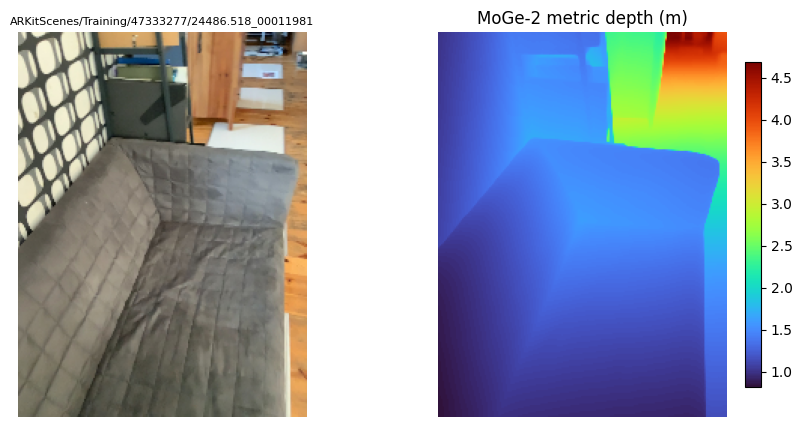

OSError: libgomp.so.1: cannot open shared object file: No such file or directory

In [7]:
import cv2, numpy as np, matplotlib.pyplot as plt

base = "/mnt/source/sam-3d-objects/artifacts/metric_scale/moge2_pointmaps/"
fname = "ARKitScenes__Training__47333277__24486.518_00011981.npy"

image_name = fname[:-4].replace("__", "/")
print(image_name)
rgb_path = f"/mnt/source/datasets_sam3d/OmniNOCS/{image_name}.jpg"

pmap = np.load(base + fname).astype(np.float32)  # [H,W,3] PyTorch3D [-X,-Y,Z], metres, NaN = invalid
rgb = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
rgb = cv2.resize(rgb, (pmap.shape[1], pmap.shape[0]))  # 1920x1440 -> 192x256 to match

valid = np.isfinite(pmap).all(-1)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb); ax[0].set_title(image_name, fontsize=8); ax[0].axis("off")
im = ax[1].imshow(np.where(valid, pmap[..., 2], np.nan), cmap="turbo")
ax[1].set_title("MoGe-2 metric depth (m)"); ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.show()

# 3D point cloud (the more honest view of a pointmap — save a PLY, open in MeshLab or an o3d viewer):

import open3d as o3d
pts = pmap[valid] * np.array([-1, -1, 1], np.float32)  # PyTorch3D -> OpenCV (x-right, y-down, z-fwd)
pc = o3d.geometry.PointCloud()
pc.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
pc.colors = o3d.utility.Vector3dVector(rgb[valid].astype(np.float64) / 255)
o3d.io.write_point_cloud("/tmp/pmap_view.ply", pc)

 

In [6]:
pmap.shape

(256, 192, 3)